In [47]:
import numpy as np
import pandas as pd
import scipy as sp
import scipy.stats
import random
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pingouin as pg
from pingouin import qqplot

### Визуализация на функциятa на правдоподобие за едномерно нормално разпределение

$$\mathcal{L}(\mu, \sigma; x_1,\dots,x_n) = -\frac{n}{2}(\ln 2 \pi + \ln \sigma ^2) - \frac{1}{2\sigma^2}\sum_{k=1}^n (x_k - \mu)^2$$

In [48]:
def one_dim_log_likelihood(samples, mu, sigma):
    """
    Calculate the population log likelihood for a one dimenisonal normal distribution
    """
    return - len(samples) / 2 *(np.log(2 * np.pi) + np.log(sigma**2))\
            - sum(samples - mu) ** 2 / (2 * sigma**2)

def plot_pdf(dist, min_pdf=0.001, *args, **kwargs):
    """
    Plot the Point Density Funciton for a distribution. The interval on the x axis is chosen so that the
    leftmost and rightmost points have a value for the PDF less than min_pdf
    """
    # define initial x interval
    start = -1
    stop = 1
    while 1:
        # generate equally spaced points on x
        x = np.linspace(start, stop, 100)
        # calculate the PDF values
        y = dist.pdf(x)
        if y[0] < min_pdf and y[-1] < min_pdf:
            # the end points for the PDF values are less than the cutoff, stop expanding the x interval
            break
        # otherwise, expand the x interval and repeat
        start -= 1
        stop += 1
    # do the plot
    plt.plot(x, y, *args, **kwargs)


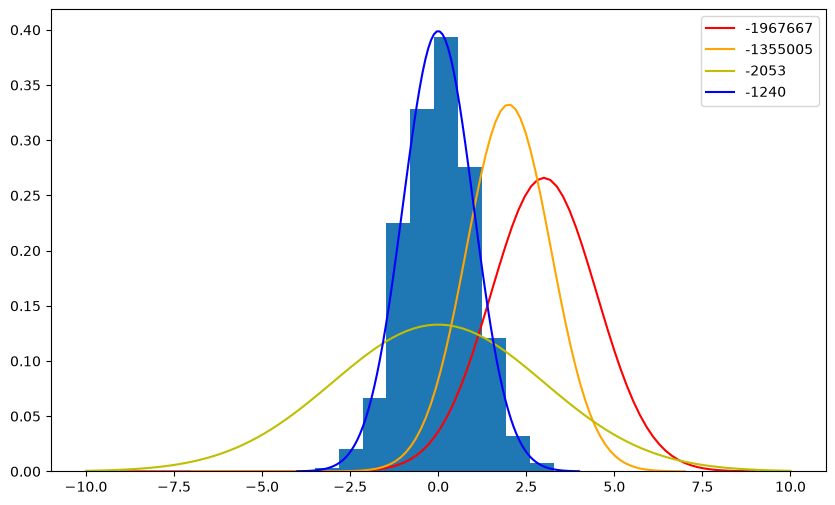

In [49]:
# generate sample with mean 0 and variance 1
real_dist = sp.stats.norm(0, 1)
samples = real_dist.rvs(1000)

fig=plt.figure(figsize=(10, 6), dpi= 100, facecolor='w', edgecolor='k')
plt.hist(samples, density=True)

# plot 3 different distributions and calculate the log likelihoods
dist1 = sp.stats.norm(3, 1.5)
likelihood = one_dim_log_likelihood(samples, 3, 1.5)
plot_pdf(dist1, c='r', label=str(int(likelihood)))

dist2 = sp.stats.norm(2, 1.2)
likelihood = one_dim_log_likelihood(samples, 2, 1.2)
plot_pdf(dist2, c='orange', label=str(int(likelihood)))

dist3 = sp.stats.norm(0, 3)
likelihood = one_dim_log_likelihood(samples, 0, 3)
plot_pdf(dist3, c='y', label=str(int(likelihood)))

# calculate the likelihood and plot for the real distribution
likelihood = one_dim_log_likelihood(samples, 0, 1)
plot_pdf(real_dist, c='b', label=str(int(likelihood)))
plt.legend()

In [50]:
one_dim_log_likelihood(samples, 0, 1)

np.float64(-1240.242135212704)

## Задача 1.
Тествайте твърдението, че ако $X \sim \mathcal{N}_p(\mu, \Sigma)$ и $A \in \pmb{M}(q, p)$ е матрица, то $A \cdot X \sim \mathcal{N}_q (\nu, \Omega) \equiv \mathcal{N}_q (A \cdot \mu, A \cdot \Sigma \cdot A^T)$.

- Тествайте за нормалност
- Тествайте $H_0: \nu = A \cdot \mu$ срещу $H_1: \nu \ne A \cdot \mu$
- Тествайте хипотезата $H_0: \Omega = A \cdot \Sigma \cdot A^T$ срещу $H_1: \Omega \ne A \cdot \Sigma \cdot A^T$

In [51]:
# Генериране на данни
np.random.seed(5)

N = 1000
p = 5
q = 3

m = np.random.uniform(-5, 5, p)
cov = np.random.uniform(-2, 2, (p, p))
cov = np.dot(cov, cov.T)

print(f'Covariance matrix {cov.shape}:\n {cov}\n')
print(f'Mean vector {m.shape}:\n {m}\n')

X = np.random.multivariate_normal(m, cov, size=N)

print(f'X shape {X.shape}:\n {X[:10]}...\n')

A = np.random.uniform(-2, 2, (q, p))

print(f'A matrix {A.shape}:\n {A}\n')

Covariance matrix (5, 5):
 [[ 3.5574555  -0.53987862 -1.64651396  0.78158651 -1.86160488]
 [-0.53987862  7.95488896  1.1609985  -1.06265212 -3.73456521]
 [-1.64651396  1.1609985   1.96698166 -0.06537194  0.78171853]
 [ 0.78158651 -1.06265212 -0.06537194  3.22623463 -1.8691014 ]
 [-1.86160488 -3.73456521  0.78171853 -1.8691014  12.20095033]]

Mean vector (5,):
 [-2.78006829  3.70732306 -2.93280845  4.18610908 -0.11588811]

X shape (1000, 5):
 [[-2.40041915  0.66171594 -3.27900535  4.93734965  2.84487847]
 [-1.00771907  2.51391178 -4.06632489  4.47220351 -0.84350006]
 [-3.42977712  2.42785658 -3.21958066  3.05964276 -1.23946288]
 [-3.51898319  1.87249706 -3.17025926  2.78972373  5.49754125]
 [-3.10007302 -0.33697277 -2.88977974  5.65084282 -0.88973431]
 [-0.47157901  1.43133171 -3.15362679  7.1661861  -0.98793725]
 [-2.58078424  1.18628442 -5.02319503  3.01713586 -3.99183237]
 [-4.10341406  3.95241355 -1.09982999  4.60709644  0.33940946]
 [-3.40514944  1.7387747   0.15800444  4.39683632 

In [52]:
# Тест за нормалност 
pg.multivariate_normality(X)

HZResults(hz=np.float64(0.8584749385915462), pval=np.float64(0.9695428716591082), normal=True)

Пресмятаме трансформираните данни и новите параметри под нулевата хипотеза.

In [53]:
# Einstein sum: (q x p) . (n x p) -> (n x q)
Y = np.einsum('ik,lk->li', A, X)

# Einstein sum: (m x p) . (p x 1) -> (m x 1)
nu = np.einsum('ik,k', A, m)

# Einstein sum: (m x p) . (p x p) . (p x m) -> (m x m) : ij,si,s
omega = np.einsum('ik,kj,jl', A, cov, A.T) 

В едномерния случай бихме използвали t-тест за проверка на нулевата хипотеза $H_0: \mu = \mu_0$ спрямо алтернативната $H_A: \mu \ne \mu_0$, чрез статистиката на Стюдънт: $t = \frac{\bar{X} - \mu_0}{s/\sqrt{n}}$. В многомерния случай имаме вектор на средните $H_0: \boldsymbol{\mu} = \boldsymbol{\mu}_0$. Еквивалентия тест е чрез статистиката на Хотелинг: $T^2 = n (\boldsymbol{\bar{X}} - \boldsymbol{\mu}_0) \boldsymbol{S}^{-1} (\boldsymbol{\bar{X}} - \boldsymbol{\mu}_0)^T$, която е пряко свързана с F статистиката $F = \frac{n - p}{p(n - 1)} T^2$

In [54]:
# Тест на Хотелинг без използване на готови функции
def multivariate_t_test(Y, mu):
    x_bar = np.mean(Y, axis=0)

    S = np.cov(Y, rowvar=False, ddof=1)
    S_inv = np.linalg.inv(S)

    diff = (x_bar-mu)

    t2 = N*np.einsum('i,ij,j', diff, S_inv, diff)

    f = (N-q)/(q*(N-1))*t2
    p_value = sp.stats.f.sf(f, q, N-q)

    return t2, f, p_value

In [55]:
t2, f, p_value = multivariate_t_test(Y, nu)

print('T-squared:', t2)
print('F:        ', f)
print('p-value:  ', p_value)

T-squared: 3.155838116890582
F:         1.0498400408875241
p-value:   0.36963865164050863


In [56]:
# Тест на  Хотелинг със `statsmodels`
res = sm.stats.test_mvmean(Y, nu)

print('T-squared:', res.t2)
print('F:        ', res.tuple[0])
print('p-value:  ', res.pvalue)

T-squared: 3.1558381168905845
F:         1.049840040887525
p-value:   0.3696386516405082


За теста на коварацианната матрица имаме следните хипотези: $H_0: \Omega = A \cdot \Sigma \cdot A^T$ срещу $H_1: \Omega \ne A \cdot \Sigma \cdot A^T$.

За целта ще използваме логаритмичната функция на правдоподобието за многомерния случай. Нека първо дефинираме функцията на плътност за нормалното разпределение.

$$
f(\mathbf{x}) 
    =   \frac{1}{\sqrt{(2\pi)^p|{\mathbf{\Sigma}}|}} 
        \exp \left( -\frac{1}{2} 
            \mathbf{(x - \boldsymbol{\mu})}^T \mathbf{\Sigma}^{-1} \mathbf{(x - \boldsymbol{\mu})}
        \right)
$$

където $\boldsymbol{x}$ и $\boldsymbol{\mu}$ са вектори с размер $(p \times 1)$ и $\mathbf{\Sigma}$ с размер $(p \times p)$.

Функцията на правдоподобие е произведението на вероятностите на наблюденията от извадката под дадено разпределение:

$$
\begin{align*}
L(\boldsymbol{\mu}, \mathbf{\Sigma} | \mathbf{x_1}, ... , \mathbf{x_N})
    &=  \prod_{i=1}^N \frac{1}{\sqrt{(2\pi)^p|{\mathbf{\Sigma}}|}} 
        \exp \left( 
            -\frac{1}{2} (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})
        \right) \\
    &=  \left( \frac{1}{\sqrt{(2\pi)^p|{\mathbf{\Sigma}}|}} \right)^N 
        \exp \left( 
            -\frac{1}{2} \sum_{i=1}^N (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})
        \right)
\end{align*}
$$

Логаритмичната функция на правдоподобие позволява да сведем горния израз от произведения в израз на сума и да съкратим експоненциалната функция. Изчислителна сила на логаритмичната форма е по-добра, защото в противен случай произведението се приближава много бързо до 0, когато $f(\mathbf{x}) \approx 0$. Също така в търсенето на оптималните параметри на разпределението въз основа на дадена извадка, аналитичното решение е по-лесно, когато имаме суми вместо произведения.

$$
\begin{align*}
l(\boldsymbol{\mu}, \mathbf{\Sigma} | \mathbf{x_1}, ... , \mathbf{x_N})
    &=
    -   \frac{Np}{2} \ln(2\pi) 
    -   \frac{N}{2} \ln(|\mathbf{\Sigma}|)
    -   \frac{1}{2} \sum_{i=1}^N \mathbf{(x_i - \boldsymbol{\mu})}^T \mathbf{\Sigma}^{-1} \mathbf{(x_i - \boldsymbol{\mu})}
\end{align*}
$$

За да тестваме $H_0$ срещу $H_A$ използваме теоремата на Wilks', която казва че $- 2 \ln \Lambda$ асимптотично следва $\chi^2$ разпределение, където $\Lambda$ e отношението на правдоподобието под нулевата хипотеза върху това под алтернативната хипотеза:

$$
- 2 \ln \Lambda = - 2 \ln \frac{L_0}{L_A} = - 2 (l_0 - l_A) \sim \chi^2_{\frac{p(p+1)}{2}}
$$

Под нулевата хипотеза оценяваме вектора на средното $\boldsymbol{\mu} = \bar{\mathbf{X}}$ и фиксираме ковариационната матрица $\boldsymbol{\Sigma} = \boldsymbol{\Omega}$. Докато, под алтернативната хипотеза, не поставяме ограничения, в резултат на което, тя съответства на максималното правдоподобие за извадката (без корекция за неотместване).

При **максималното правдоподобие** вектора на средните съответства на извадковото средно:

$$
\frac{\partial l}{\partial \boldsymbol{\mu}} = 0 \iff \sum_{i=1}^{N} \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) = 0 \iff \sum_{i=1}^{N} \mathbf{x}_i - N\boldsymbol{\mu} = 0 \iff \boldsymbol{\mu} = \frac{\sum_{i=1}^{N} \mathbf{x}_i}{N}
$$

Където сме използвали правилото за матрично диференциране

$$
\frac{\partial (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})}{\partial \boldsymbol{\mu}} = 2\mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) \tag{1}
$$

Ковариационната матрица съответства на извадковата ковариационна матрица:

$$
\frac{\partial l}{\partial \mathbf{\Sigma}^{-1}} = 0 \iff \frac{N}{2}\mathbf{\Sigma} - \frac{1}{2}\mathbf{W}^T = 0 \iff \mathbf{\Sigma} = \frac{1}{N}\mathbf{W} = \frac{1}{N}\sum_{i=1}^{N} (\mathbf{x}_i - \mathbf{\mu})^T (\mathbf{x}_i - \mathbf{\mu})
$$

Където сме използвали:

- Следа на скалар и циклично правило

$$ 
    \sum_{i=1}^{N} (\mathbf{x}_i - \mathbf{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \mathbf{\mu}) = \text{tr}\left(\mathbf{\Sigma}^{-1} \underbrace{\sum_{i=1}^{N} (\mathbf{x}_i - \mathbf{\mu})^T (\mathbf{x}_i - \mathbf{\mu})}_{\mathbf{W}}\right) = \text{tr}(\mathbf{\Sigma}^{-1} \cdot \mathbf{W}) 
$$

- Равенство $|\mathbf{A}^{-1}| = |\mathbf{A}|^{-1}$
$$
\ln|\mathbf{\Sigma}| = \ln(|\mathbf{\Sigma}^{-1}|^{-1}) = - \ln|\mathbf{\Sigma}^{-1}|
$$

- Преобразувано правдоподобие

$$ 
    l(\mathbf{\mu}, \mathbf{\Sigma} \mid \mathbf{x}_1, \dots, \mathbf{x}_N) = -\frac{pN}{2}\ln(2\pi) + \frac{N}{2}\ln|\mathbf{\Sigma}^{-1}| - \frac{1}{2}\text{tr}(\mathbf{\Sigma}^{-1} \cdot \mathbf{W}) 
$$

- Правила за матрично диференциране

$$
\begin{align}
\frac{\partial \text{tr}(\mathbf{\Sigma}^{-1} \cdot \mathbf{W})}{\partial \mathbf{\Sigma}^{-1}} &= \mathbf{W}^T = \mathbf{W} \tag{1} 
\\[8pt]
\frac{\partial \ln|\mathbf{\Sigma}^{-1}|}{\partial \mathbf{\Sigma}^{-1}} &= (\mathbf{\Sigma}^{-1})^{-1} = \mathbf{\Sigma} \tag{2}
\end{align}
$$


In [57]:
def log_likelihood(x, mu, sig):
    N = x.shape[0]
    p = x.shape[1]

    sig_inv = np.linalg.inv(sig)
    sig_det = np.linalg.det(sig)

    # N-sum of (N x p)(p x p)(p x N) quadratic forms
    diff = x - mu
    distance = np.einsum('kj,ij,ki', diff, sig_inv, diff)

    ll = - (N*p / 2) * np.log(2 * np.pi) - (N / 2) * np.log(sig_det) - (1 / 2) * distance
   
    return ll

In [58]:
def multivariate_test_cov(x, omega):
    x_bar = np.mean(x, axis=0)
    S = np.cov(x, rowvar=False, ddof=0)

    l_0 = log_likelihood(x, x_bar, omega)
    l_a = log_likelihood(x, x_bar, S)

    p = x.shape[1]
    
    lambda_stat = -2 * (l_0 - l_a)
    p_value = sp.stats.chi2.sf(lambda_stat, df=p*(p+1)/2)

    return lambda_stat, p_value
    

In [59]:
lambda_stat, p_value = multivariate_test_cov(Y, omega)

print("Likelihood ratio test statistic:", lambda_stat)
print("p-value:", p_value)

Likelihood ratio test statistic: 8.783235116119613
p-value: 0.18614077383590735


In [60]:
# Сверяваме резултатите с имплементация от `statsmodels`.
# Maлката разлика се дължи на корекцията на Бартлет използвана в `statsmodels` вместо тестовата статистика на Уилкс. За N->inf разликата изчезва, както и гласи теоремата на Уилкс.
S = np.cov(Y, rowvar=False, ddof=0)
result = sm.stats.test_cov(S, N, omega)

print('Likelihood ratio test statistic (bartlet):', result.statistic)
print('p-value:', result.pvalue)

Likelihood ratio test statistic (bartlet): 8.764935121902889
p-value: 0.1872359060947392


## Задача 2.
Нека $X \sim \mathcal{N}_p(\mu, \Sigma)$. Нека фиксираме произволно $k<p$ и произвoлен вектор от естествени числа $a = (a_1,..., a_k)$, такъв че $a_i \leq p, \forall i$ и $a_i \neq a_j, \forall i, j$ (вектор от индекси на X). 

Тествайте твърдението, че всеки вектор $Y=(X_{a_1}, ...,X_{a_k})$ от компоненти на $X$ с размерност $k < p$ е разпределено нормалнo като $Y\sim\mathcal{N}_k (\nu, \Omega)$, където $\nu_i = \mu_{a_i}$ и $\Omega_{ij} = \Sigma_{a_ia_j}$.
- Тествайте $Y$ за нормалност
- Тествайте $H_0: \nu_i = \mu_{a_i}$
- ** Тествайте хипотезата $H_0: \Omega_{ij} = \Sigma_{a_ia_j}$

In [61]:
np.random.seed(25)

p = 7
N = 1000

m = np.random.uniform(-5, 5, p)
cov = np.random.uniform(-2, 2, (p, p))
cov = np.dot(cov, cov.T)

print(f'Covariance matrix {cov.shape}')
print(f'Mean vector {m.shape}')

X = np.random.multivariate_normal(m, cov, size=N)

print(f'X shape {X.shape}')

k = np.random.randint(1, p-1)

a = np.random.choice(range(p), k, replace=False)

Y = X[:, a]

print(f'a vector {a}')
print(f'Y shape {Y.shape}')

Covariance matrix (7, 7)
Mean vector (7,)
X shape (1000, 7)
a vector [2 4 6]
Y shape (1000, 3)


In [62]:
pg.multivariate_normality(Y)

HZResults(hz=np.float64(0.8924312919585189), pval=np.float64(0.39428652284770566), normal=True)

Правим t-тест с нулева хипотеза $H_0: \nu = \mu \iff \mathbb{E}Y_i = \mu_{a_i}$

In [63]:
t2, f, p_value = multivariate_t_test(Y, m[a])

print('T-squared:', t2)
print('F:        ', f)
print('p-value:  ', p_value)

T-squared: 3.0372125741694553
F:         1.0103773561718208
p-value:   0.38732053049956217


In [64]:
lambda_stat, p_value = multivariate_test_cov(Y, cov[np.ix_(a, a)])

print("Likelihood ratio test statistic:", lambda_stat)
print("p-value:", p_value)

Likelihood ratio test statistic: 8.806990738805325
p-value: 0.18472727561900867


## Задача 3. (домашна)
Тествайте твърдението, че ако $X \sim \mathcal{N}_p(\mu, \Sigma)$ и $d \in \mathbb{R}^p$ е $p$-мерен вектор, то $X + d \sim \mathcal{N}_p (\mu + d, \Sigma)$
- Тествайте за нормалност
- Тествайте $H_0: \mathbb{E}(X + d) = \mu + d$
- ** Тествайте хипотезата $H_0: Cov(X + d) = \Sigma$

In [65]:
np.random.seed(25)

p = 7
N = 1000

m = np.random.uniform(-5, 5, p)
cov = np.random.uniform(-2, 2, (p, p))
cov = np.dot(cov, cov.T)

print(f'Covariance matrix {cov.shape}')
print(f'Mean vector {m.shape}')

X = np.random.multivariate_normal(m, cov, size=N)

print(f'X shape {X.shape}')

d = np.random.randint(-2, 2, size=p)

Y = X + d

print(f'Y shape {Y.shape}')

Covariance matrix (7, 7)
Mean vector (7,)
X shape (1000, 7)
Y shape (1000, 7)


In [66]:
t2, f, p_value = multivariate_t_test(Y, m + d)

print('T-squared:', t2)
print('F:        ', f)
print('p-value:  ', p_value)

T-squared: 5.146888145253597
F:         1.7121946882942398
p-value:   0.16280237850360993


In [67]:
lambda_stat, p_value = multivariate_test_cov(Y, cov)

print("Likelihood ratio test statistic:", lambda_stat)
print("p-value:", p_value)

Likelihood ratio test statistic: 23.038773668391514
p-value: 0.7310974341026684


## Задача 4. (домашна)
Повторете теста на хипотезата $H_0: \Omega = A \cdot \Sigma \cdot A^T$ от зад. 1 без да изпозлвате функцията log_likelihood. Вместо това изпозлвайте директния израз за $W = -2\ln\Lambda$:
$$
W = -pN - N \ln |\mathbf{\Omega}^{-1} \mathbf{S}| + N \mathrm{tr}\big(\mathbf{\Omega^{-1}}\mathbf{S}\big)$$

#### Директен израз за W:

Преобразуваме логаритмичното правдоподобие:

$$\begin{align*}
l_0 &= -\frac{pN}{2} \ln(2\pi) - \frac{N}{2} \ln |\mathbf{\Sigma}| - \frac{1}{2} \underbrace{\sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu})}_{(*)}
\end{align*}$$

$$\begin{align*}
(*) \quad \frac{1}{2} \sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) &= \frac{1}{2} \sum_{i=1}^{N} \text{tr}\left[ (\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x}_i - \boldsymbol{\mu}) \right] \\
&= \frac{1}{2} \sum_{i=1}^{N} \text{tr}\left[ (\mathbf{x}_i - \boldsymbol{\mu})(\mathbf{x}_i - \boldsymbol{\mu})^T \mathbf{\Sigma}^{-1} \right] \\
&= \frac{1}{2} \text{tr}\left[ \mathbf{\Sigma}^{-1} \underbrace{\sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu})(\mathbf{x}_i - \boldsymbol{\mu})^T}_{= N \mathbf{S}} \right] \\
&= \frac{N}{2} \text{tr}(\mathbf{\Sigma}^{-1} \cdot \mathbf{S})
\end{align*}$$

$$\Rightarrow l = -\frac{pN}{2} \ln(2\pi) - \frac{N}{2} \ln |\mathbf{\Sigma}| - \frac{N}{2} \text{tr}(\mathbf{\Sigma}^{-1} \cdot \mathbf{S})$$

където $\mathbf{S} = \frac{1}{N}\sum_{i=1}^{N} (\mathbf{x}_i - \boldsymbol{\mu})(\mathbf{x}_i - \boldsymbol{\mu})^T$ е извадковата ковариационна матрица при максималното правдоподобие. (без корекция за неотместване)

За $l_0$: $\mathbf{\Sigma} = \mathbf{\Omega}$

$$\Rightarrow l_0 = -\frac{pN}{2} \ln(2\pi) - \frac{N}{2} \ln |\mathbf{\Omega}| - \frac{N}{2} \text{tr}(\mathbf{\Omega}^{-1} \cdot \mathbf{S})$$

---

За $l_A$: $\mathbf{\Sigma} = \mathbf{S}$ (според максималното правдоподобие)

$$\begin{align*}
l_A &= -\frac{pN}{2} \ln(2\pi) - \frac{N}{2} \ln |\mathbf{S}| - \frac{N}{2} \overbrace{\text{tr}(\mathbf{S}^{-1} \cdot \mathbf{S})}^{\text{tr}(I_p)} \\
&= -\frac{pN}{2} \ln(2\pi) - \frac{N}{2} \ln |\mathbf{S}| - \frac{Np}{2}
\end{align*}$$

---

Директна формула за $W = -2 \ln \Lambda$:

$$\begin{align*}
W &= -2(l_0 - l_A) \\
&= -pN \ln(2\pi) - N \ln |\mathbf{\Omega}| - Np + pN \ln(2\pi) + N \ln |\mathbf{S}| + N \text{tr}(\mathbf{\Omega}^{-1} \mathbf{S}) \\
&= -Np - N \ln |\mathbf{\Omega}^{-1} \mathbf{S}| + N \text{tr}(\mathbf{\Omega}^{-1} \mathbf{S})
\end{align*}$$

In [68]:
np.random.seed(5)

N = 1000
p = 5
q = 3

m = np.random.uniform(-5, 5, p)
cov = np.random.uniform(-2, 2, (p, p))
cov = np.dot(cov, cov.T)

print(f'Covariance {cov.shape}')
print(f'Mean {m.shape}')

X = np.random.multivariate_normal(m, cov, size=N)

print(f'X {X.shape}')

A = np.random.uniform(-2, 2, (q, p))

print(f'A {A.shape}')

Y = np.einsum('ik,lk->li', A, X)

print(f'Y {Y.shape}')

omega = np.einsum('ik,kj,jl', A, cov, A.T) 

print(f'Omega {omega.shape}')

Covariance (5, 5)
Mean (5,)
X (1000, 5)
A (3, 5)
Y (1000, 3)
Omega (3, 3)


In [69]:
omega_inv = np.linalg.inv(omega)
S = np.cov(Y, rowvar=False, ddof=0)

W = - q*N - N*np.log(np.linalg.det(omega_inv @ S)) + N*np.trace(omega_inv @ S)

print(f'Likelihood ratio test statistic: {W}')

Likelihood ratio test statistic: 8.783235116109154


In [70]:
lambda_stat, p_value = multivariate_test_cov(Y, omega)

print("Likelihood ratio test statistic:", lambda_stat)
print("p-value:", p_value)

Likelihood ratio test statistic: 8.783235116119613
p-value: 0.18614077383590735
